# Grid of H<sub>2</sub>O escape rates

This notebook compares the grid of H<sub>2</sub>O escape rates calculated by Wind-AE ([github.com/mibroome/wind-ae](github.com/mibroome/wind-ae)) in Tao et al. 2026 ([ADS link](ADS link)).<br>

The escape rates of H<sub>2</sub>O are compared to the formulation of H<sub>2</sub>-He escape provided by Eq. 31 of Owen & Wu 2017 ([https://ui.adsabs.harvard.edu/abs/2017ApJ...847...29O/abstract](https://ui.adsabs.harvard.edu/abs/2017ApJ...847...29O/abstract)).

The figures generated in this notebook are used in Tao et al. 2026.

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

In [2]:
from pathlib import Path
dir_grids = Path("./Grids")
dir_figs = Path("./Figures")

# Constants and functions

In [3]:
## astronomical constants        
kb = 1.38065e-16 # boltzmann's constant
mh = 1.673558e-24 # mass of hydrogen atom in grams
sigma = 5.6704e-5 # stefan-Boltzmann constant

G=6.67408e-8 # Gravitational constant

earth_mass_to_g = 5.972e27
earth_radius_to_cm = 6.371e8
Mearth = earth_mass_to_g*1e-3 # kg
Rearth = earth_radius_to_cm*1e-2 # m
rho_earth_cgs = 5.51 # density of Earth
year_to_sec = 31557600. # number of seconds in a year
gyr_to_sec = 1e9*year_to_sec
day_to_sec = 86400. # number of secconds in a day

Tsun = 5778. #K
Rsun = 6.9551e8 # m
Msun = 1.9885e30 #kg
Lsun = 3.828e26 #W
Fxuv_earth = 0.67e-3 #W/m^2
Fxuv_earth_cgs = 4.666
au_to_cm = 1.496e13
AU = au_to_cm*1e-2
Period_Earth = 365.25 #days

#My units in SI
me = 5.972e24
re = 6.371e6

Ggrav=6.67408e-11
sigmasb=5.670374419e-8
gyr=gyr_to_sec
Rmol=8.31446261815324
Nav=6.02214076e23
Teq_e=5772.0*np.sqrt(1.362e9/(4.0*1.5e11))

In [4]:
# Standard energy-limited formalism
def massloss_energy_limited(
    fxuv   :float,
    mass   :float,
    radius :float,
    eff  :float = 1.0,
    beta :float = 1.0,
    ) -> float:
    """
    Returns the mass loss rate from a planet using the
    energy-limited model.
    Required parameters must be defined in the state,
    optional parameters can be provided through model keywords.

    Parameters
    ----------
    fxuv    : float, XUV flux of the star at planet orbit
    mass    : float, planet mass 
    radius  : float, planet radius 
    eff  : float|callable (optional),
            evaporation efficiency.
    beta    : float, Rxuv/Rpl
    Returns
    -------
    mloss  : float, mass loss rate in kg/s
    """
    mloss = (beta**2)*eff*np.pi*fxuv*(radius**3)/(Ggrav*mass)
    return mloss

In [5]:
#-- Owen & Wu 2017
def efficiency(mp,rp,mstar,sep):
    '''
    Efficiency of photoevaporative atmospheric H/He mass loss.
    Owen & Wu 2017
    '''
    v_esc = np.sqrt(2*Ggrav*mp / rp) #escape velocity at planet surface
    eff = 0.1 * (v_esc / 15e3)**(-2) #mass-loss efficiency, uncorrected
    
    #Roche lobe correction, Salz+ 2016a
    xi = (sep / rp) * (mp / (3*mstar))**(1/3)   #ξ
    k_diff = 1 - 3/(2 * xi) + 1/(2 * xi**3)     #fractional gravitational potential energy difference
    
    efficiency = eff/k_diff #corrected efficiency
    return efficiency

def find_Lxuv(age,lstar):
    '''
    High-energy luminosity (X + UV) emitted by the star
    Sanz-Forçada+2011
    '''

    #L_xuv in non-saturation regime
    Lx = 1.89e21 * (age/Gyr)**(-1.55)
    Leuv = 10**(3.82) * Lx**0.86
    Lxuv = Lx + Leuv

    #L_xuv in saturation regime
    Lxsat = lstar * 6.3e-4
    Leuvsat = 10**(3.82) * Lxsat**0.86
    Lxuvsat = Lxsat + Leuvsat
    new_lxuv = np.minimum(Lxuv,Lxuvsat) #final Lxuv
    return new_lxuv

def mdot_ow17(fxuv,mstar,mp,rp,sep):
    '''
    Mass loss rate.
    Owen & Wu 2017
    '''
    eta = efficiency(mp,rp,mstar,sep)
    mdot = eta * np.pi * (fxuv*rp**3) / (Ggrav*mp)
    return mdot


In [6]:
# Differential escape of H and O
### following the formalism of Bolmont et al. 2017 (2017MNRAS.464.3728B)

# mass of H and O
amu = 1.66053906892e-26 # in kg
mH = amu*1.008
mO = amu*15.999

# stoechiometry of H2O molecule (molar)
XO = 1/3
XH = 2/3

kb = 1.380649e-23 #Boltzmann constant: J . K^-1
b_col = 2.2e21 #O on H collision parameter: m^-1 . sec^-1, from Kasting and Pollack 1983

def func_FH(df,b_col):
    '''
    Mass loss flux of hydrogen (kg/s/m^2).
    '''
    FM = df["Mdot"]/(4*np.pi*(df["Rp"]*re)**2)
    top = FM + mO*XO*(mO-mH) * b_col*df["grav"]/(kb*df["Teq"])
    bottom = mH + mO*XO/XH
    FH = top/bottom
    
    # df.loc[:,"FH"] = FH
    return FH

def func_mc(df,b_col):
    '''
    Cross-over mass.
        mc = +infty ---> rF = XO/XH = 0.5 ---> stoechiometric escape of H and O
        mc = mO     ---> rF = 0           ---> only H escape
        mc < mO     ---> rF = 0           ---> only H escape
    '''
    FH = func_FH(df,b_col)
    mc = mH + kb*df["Teq"]*FH / (b_col*df["grav"]*XH)

    # df.loc[:,"mc"] = mc
    # df.loc[:,"mc_amu"] = mc/amu
    return mc,mc/amu
    
def func_rF(df,b_col):
    '''
    Ratio of escape fluxes: rF = FO/FH
        rF = XO/XH = 0.5 ---> stoechiometric escape of H and O
        rF = 0           ---> only H escape
    '''
    mc, mc_amu = func_mc(df,b_col)
    rF = XO/XH * (mc - mO) / (mc - mH)
    rF = np.clip(rF,a_min = 0, a_max = None)

    # df.loc[:,"rF"] = rF
    return rF

In [7]:
file = dir_grids / "windae_nobolo_static_110325.dat"

df = pd.read_csv(file,sep="\t",header=27)

# Keys: 'Mp', 'Rp', 'grav', 'Teq', 'a', 'Fxuv', 'mstar', 'lstar', 'Mdot',
#       'MdotOW17', 'ramp_to', 'run_wind', 'rochelim'

# Photoevaporation mass loss rate using the energy-limited formalism assuming a 100% efficiency
df["MdotEL"] = massloss_energy_limited(df["Fxuv"]*Fxuv_earth_cgs,
                                       df["Mp"]*Mearth,
                                       df["Rp"]*Rearth,)

# Effective efficiency: efficiency if it was calculated using the energy limited (EL) formalism
df["effective-efficiency-wind-ae"] = df["Mdot"] / df["MdotEL"]
# Efficiency calculated using the OW17 formalism
df["efficiency-OW17"] = efficiency(
                                    df["Mp"]*Mearth,
                                    df["Rp"]*Rearth,
                                    df["mstar"]*Msun,
                                    df["a"]*AU,)

# Photoevaporation mass loss rate using the OW17 formulation + Roche Lobe correction
df["MdotOW17"] = mdot_ow17(df["Fxuv"]*Fxuv_earth_cgs,
                                       df["mstar"]*Msun,
                                       df["Mp"]*Mearth,
                                       df["Rp"]*Rearth,
                                       df["a"]*AU,)

# Atmospheric scale-height calculated at the planet's transiting radius
df["H"] = (8.314*df["Teq"])/(18e-3*df["grav"])

# Jeans escape parameter calculated at the planet's transiting radius
df["Lambda"] = df["Rp"]*Rearth / df["H"]

# Escape velocity calculated at the planet's transiting radius
df["v_esc"] = np.sqrt(2*Ggrav*(df["Mp"]*Mearth) / (df["Rp"]*Rearth))

# Thermal velocity calculated with the equilibrium temperature
df["v_th"] = np.sqrt(2*kb*df["Teq"] / (2*mH+mO))

# Mask corresponding to successful runs
### "ramp_to"  : successfully produced the atmosphere structure in Wind-AE by ramping to the desired input parameters (0- ramp success, else- ramp failed)
### "run_wind" : the produced atmosphere structure has an escaping wind (0- wind launched, else- wind failed)
### "rochelim" : checking for Roche lobe overflow (0- planet outside Roche limit, 1- planet within Roche limit)
df_valid = df[df["ramp_to"]+df["run_wind"]+df["rochelim"] == 0]

print("Number of atmospheric models: ",len(df))
print("   Roche-stable:              ",len(df[df["rochelim"] == 0]))
print("   Successfully ramped:       ",len(df[df["ramp_to"]+df["rochelim"]== 0]))
print("   Successfully launched wind:",len(df[df["ramp_to"]+df["run_wind"]+df["rochelim"]== 0]))
print("Number of valid models:       ",len(df_valid))


Number of atmospheric models:  6000
   Roche-stable:               2376
   Successfully ramped:        2026
   Successfully launched wind: 2026
Number of valid models:        2026


# Publication figures

This section contains the main figures that are included in the publication.

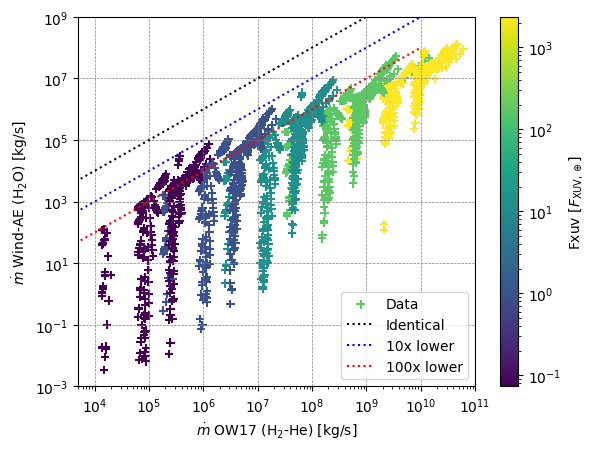

In [8]:
# -----------------------------------------------------------

# Mdot Wind-AE vs MdotOW17.
### Escape rate of H2O is mostly 10 to 100 lower than what is obtained when assuming escape rate of H2-He from OW17.

# Convenience array
x = np.logspace(1,10)

output_file = dir_figs / "mdot_windae-vs-ow17.pdf"

plt.scatter(df_valid["MdotOW17"],df_valid["Mdot"],marker='+',alpha=1,
            c=df_valid["Fxuv"],norm=matplotlib.colors.LogNorm(),
            label="Data")
plt.plot(x,x,c='k',ls=':',label="Identical")
plt.plot(x,0.1*x,c='b',ls=':',label="10x lower")
plt.plot(x,0.01*x,c='r',ls=':',label="100x lower")
cbar = plt.colorbar();plt.xscale('log');plt.yscale('log')
cbar.set_label(r"Fxuv [$F_{\mathrm{XUV},\oplus}$]")
plt.ylabel(r'$\dot{m}$ Wind-AE (H$_2$O) [kg/s]')
plt.xlabel(r'$\dot{m}$ OW17 (H$_2$-He) [kg/s]')
plt.xlim(5e3,1e11)
plt.ylim(1e-3,1e9)
plt.legend(loc=0)
plt.grid(ls="--",c='gray',lw=0.5)
plt.savefig(output_file,dpi=120,bbox_inches="tight")
plt.show()


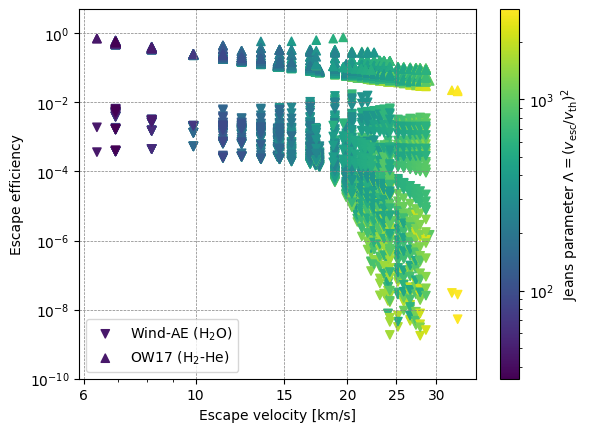

In [9]:
# -----------------------------------------------------------

# Effective efficiency = Mdot Wind-AE/MdotEL as a function of Lambda.

output_file = dir_figs / "efficiency_windae-vs-ow17.pdf"

plt.scatter(df_valid["v_esc"]/1e3,df_valid["effective-efficiency-wind-ae"],marker='v',
            c=df_valid["Lambda"],norm=matplotlib.colors.LogNorm(),
            label=r"Wind-AE (H$_2$O)")
plt.scatter(df_valid["v_esc"]/1e3,df_valid["efficiency-OW17"],marker='^',
            c=df_valid["Lambda"],norm=matplotlib.colors.LogNorm(),
            label=r"OW17 (H$_2$-He)")
cbar=plt.colorbar()
plt.xscale('log')
plt.xticks([6,10,15,20,25,30])
ax = plt.gca()
ax.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
plt.yscale('log')
# cbar.set_label(r"Fxuv [$F_{\mathrm{XUV},\oplus}$]")
cbar.set_label(r"Jeans parameter $\Lambda = (v_\mathrm{esc}/v_\mathrm{th})^2$")
plt.ylabel('Escape efficiency')
plt.xlabel('Escape velocity [km/s]')
plt.ylim(1e-10,5)
plt.grid(ls="--",c='gray',lw=0.5)
plt.legend(loc=0)
plt.savefig(output_file,dpi=120,bbox_inches="tight")
plt.show()


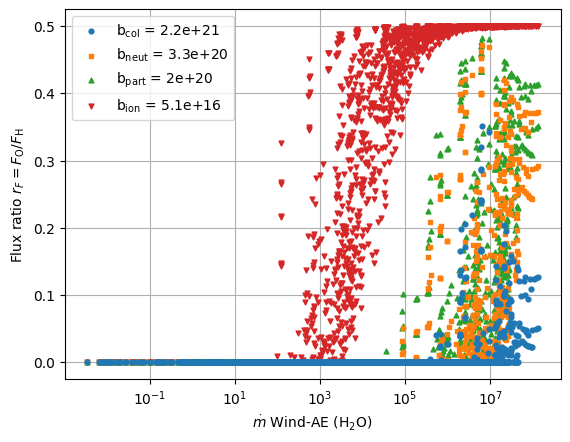

In [10]:
# -----------------------------------------------------------

# Master plot 3: rF as a fct of Mdot.

output_file = dir_figs / "flux-ratio-vs-b_col.pdf"

#O on H collision parameter: m^-1 . sec^-1
b_col1 = 2.2e21 # from Kasting and Pollack 1983

T_thermo = 5500 # temperature of the thermosphere (in K) to calculate collision parameter
b_neut = 7.25e17 * T_thermo**0.71 # neutral H and O: b_col = 7.25e17 * T**0.71, from Cooper et al. 1984
b_part = 3.66e16 * T_thermo # H - O+: b_col = 3.66e16 * T, from Zahnle et al. 1990
b_ion = 2.29e7 * T_thermo**(5/2) # H+ - O+: b_col = 2.29e7 * T**(5/2), from Zahnle et al. 1990

b_col_list = [
    b_col1,
    b_neut,
    b_part,
    b_ion,
]

b_col_name = [
    r"b$_\mathrm{col}$",
    r"b$_\mathrm{neut}$",
    r"b$_\mathrm{part}$",
    r"b$_\mathrm{ion}$",
]

marker_list = ["o", "s", "^", "v"]

for b_col,name,marker in zip(b_col_list,b_col_name,marker_list):
    rF = func_rF(df_valid,b_col)
    b_label = name+f" = {b_col:.2g}"

    plt.scatter(df_valid["Mdot"],rF,
        # c=df_valid["Fxuv"],norm=matplotlib.colors.LogNorm(),
        label=b_label,
        marker=marker,
        s=12,
        zorder=int(np.log(b_col)))

plt.legend()
# plt.colorbar()
plt.xscale('log')
plt.ylabel(r'Flux ratio $r_F = F_\mathrm{O}/F_\mathrm{H}$')
plt.xlabel(r'$\dot{m}$ Wind-AE (H$_2$O)')
plt.grid()

plt.savefig(output_file,dpi=120,bbox_inches="tight")
plt.show()

# Additional figures

This section contains additional figures that are not in the publication, but that still provide additional ancillary information.

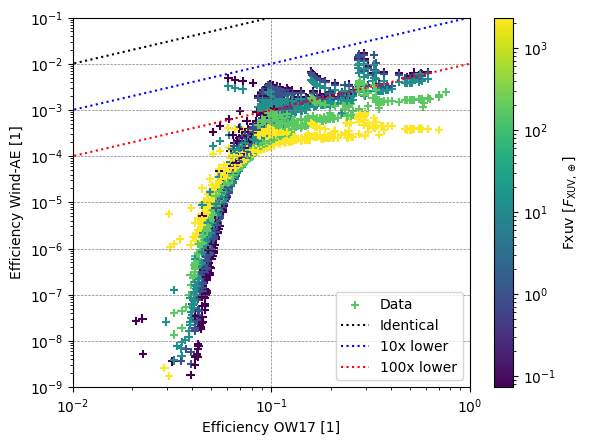

In [11]:
# -----------------------------------------------------------

# Efficiency Wind-AE vs Efficiency OW17.
### The efficiency of H2O is generally 100 lower than what is obtained when assuming escape rate of H2-He from OW17.

# Convenience array
x = np.logspace(-10,0)

plt.scatter(df_valid["efficiency-OW17"],df_valid["effective-efficiency-wind-ae"],marker='+',alpha=1,
            #c=df_valid["v_esc"]/1e3,
            c=df_valid["Fxuv"],norm=matplotlib.colors.LogNorm(),
            label="Data")
plt.plot(x,x,c='k',ls=':',label="Identical")
plt.plot(x,0.1*x,c='b',ls=':',label="10x lower")
plt.plot(x,0.01*x,c='r',ls=':',label="100x lower")
cbar = plt.colorbar()
plt.xscale('log');plt.yscale('log')
cbar.set_label(r"Fxuv [$F_{\mathrm{XUV},\oplus}$]")
plt.ylabel('Efficiency Wind-AE [1]')
plt.xlabel('Efficiency OW17 [1]')
plt.xlim(1e-2,1e0)
plt.ylim(1e-9,1e-1)
plt.legend(loc=0)
# plt.savefig("efficiency_windae-vs-ow17.pdf",dpi=300,bbox_inches="tight")
plt.grid(ls="--",c='gray',lw=0.5)
plt.show()


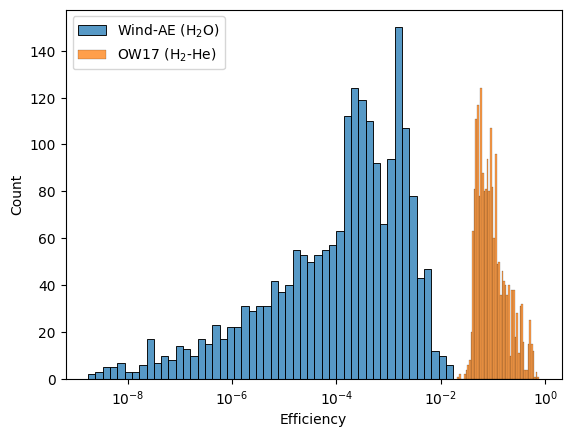

In [12]:
# -----------------------------------------------------------
# Histogram of efficiency values Wind-AE vs OW17
### Each histogram uses 50 bins so that underlying distributions are comparable in their overall shapes.

sns.histplot(df_valid["effective-efficiency-wind-ae"],
             bins=50,log_scale=(True,False),
            label=r"Wind-AE (H$_2$O)")
sns.histplot(df_valid["efficiency-OW17"],
             bins=50,log_scale=(True,False),
             label=r"OW17 (H$_2$-He)")
plt.xlabel("Efficiency")
plt.legend(loc=2)
plt.show()